In [10]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk openpyxl spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [11]:
!pip install bertopic

# Middle Term Test 2 - COVID-19 Fake News Detection

## 1.1 Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
from nltk.util import ngrams
from nltk.text import Text
import spacy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1.2 Load Dataset

In [ ]:
# cargar datasets test, train, val, y text_with_labels
train_df = pd.read_excel('data/Constraint_English_Train.xlsx')
val_df = pd.read_excel('data/Constraint_English_Val.xlsx')
test_df = pd.read_excel('data/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('data/english_test_with_labels.xlsx')

'''train_df = pd.read_excel('/content/Constraint_English_Train.xlsx')
val_df = pd.read_excel('/content/Constraint_English_Val.xlsx')
test_df = pd.read_excel('/content/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('/content/english_test_with_labels.xlsx')'''

# info basica
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# mostrar tweets completos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

train_df.head(15)

Train shape: (6420, 3)
Validation shape: (2140, 3)
Test shape: (2140, 2)


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,real
1,2,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,real
2,3,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,real
4,5,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,real
5,6,"Covid Act Now found ""on average each person in Illinois with COVID-19 is infecting 1.11 other people. Data shows that the infection growth rate has declined over time this factors in the stay-at-home order and other restrictions put in place."" https://t.co/hhigDd24fE",real
6,7,If you tested positive for #COVID19 and have no symptoms stay home and away from other people. Learn more about CDC’s recommendations about when you can be around others after COVID-19 infection: https://t.co/z5kkXpqkYb. https://t.co/9PaMy0Rxaf,real
7,8,Obama Calls Trump’s Coronavirus Response A Chaotic Disaster https://t.co/DeDqZEhAsB,fake
8,9,"???Clearly, the Obama administration did not leave any kind of game plan for something like this.??�",fake
9,10,Retraction—Hydroxychloroquine or chloroquine with or without a macrolide for treatment of COVID-19: a multinational registry analysis - The Lancet https://t.co/L5V2x6G9or,fake


As a simple analysis we can see that there are shorter and longer tweets but most use hashtags and links to sources. We can also see that some use figures to describe what they say, in this small sample all those using figures are real but we will analyze more things below.

## 1.3 EDA (linguistic analysis)

### 1.3.1 Class distribution analysis

In [14]:
nltk.download('punkt')
nltk.download('stopwords')
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
df = train_df.copy()
df = df[['tweet', 'label']]

In [16]:
# distribución de clases
df['label'].value_counts()

,count
label,
real,3360
fake,3060


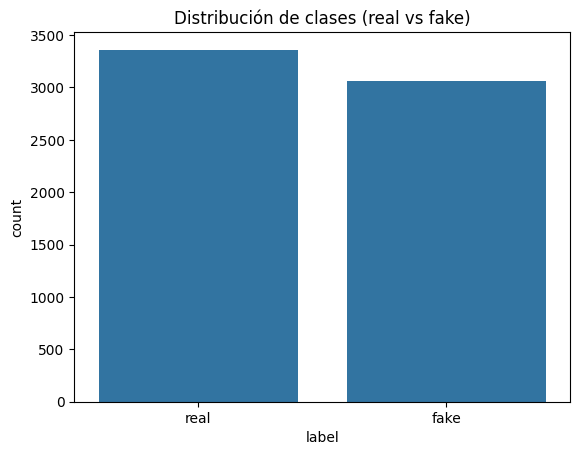

In [17]:
sns.countplot(data=df, x='label')
plt.title("Distribución de clases (real vs fake)")
plt.show()

There are more real than fake tweets, this will give us problems in numerical comparisons since they will be unbalanced.

### 1.3.4 Tokenization + stopwords + frequency

In [18]:
stop_words = set(stopwords.words("english"))

In [19]:
def preprocess_nltk(text):
    tokens = word_tokenize(text)
    return [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

In [20]:
df['tokens'] = df['tweet'].astype(str).apply(preprocess_nltk)
df[['tweet', 'tokens']].head()

,tweet,tokens
0,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,"[cdc, currently, reports, deaths, general, discrepancies, death, counts, different, sources, small, explicable, death, toll, stands, roughly, people, today]"
1,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,"[states, reported, deaths, small, rise, last, tuesday, southern, states, reported, deaths, https]"
2,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,"[politically, correct, woman, almost, uses, pandemic, excuse, reuse, plastic, bag, https, coronavirus, nashville]"
3,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,"[indiafightscorona, covid, testing, laboratories, india, august, tests, done, profbhargava, dg, icmrdelhi, staysafe, indiawillwin, https]"
4,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,"[populous, states, generate, large, case, counts, look, new, cases, per, million, today, smaller, states, showing, cases, per, million, california, texas, al, ar, id, ks, ky, la, ms, nv, sc, https]"


### 1.3.2 Tweet length

In [21]:
df['tweet_length'] = df['tokens'].apply(len)

In [22]:
# estadisticas descriptivas por clase
df.groupby('label')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,12.724837,18.592957,1.0,8.0,11.0,15.0,835.0
real,3360.0,16.702083,5.931704,2.0,12.0,17.0,21.0,34.0


The average is 12 for fake tweets and 16 for real ones, not much difference.

The maximum length of fake tweets is larger (835) but let's see why below:

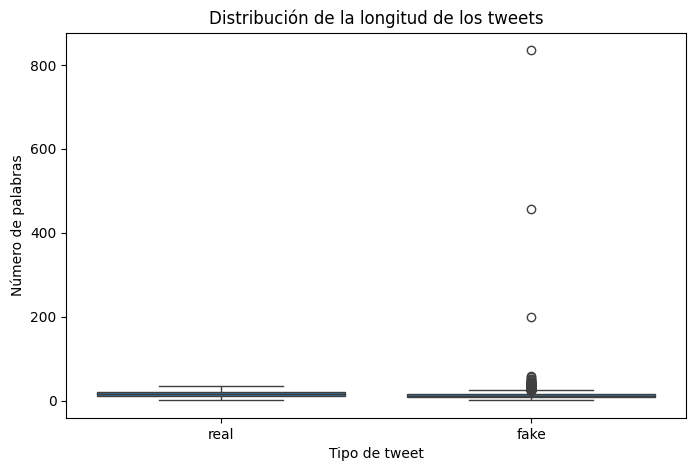

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='tweet_length')
plt.title("Distribución de la longitud de los tweets")
plt.ylabel("Número de palabras")
plt.xlabel("Tipo de tweet")
plt.show()

Fake tweets have several outliers or anomalies which are tweets with extremely large word counts.

In [24]:
df[df['tweet_length'] > 100][['tweet', 'label']].head()

tweet  \
270   Amoxi" Capsule made in US is the only medicine that can completely cure COVID-19.\nEgyptian Health Minister arrive in Italy with secret coronavirus cure.\n Dr Charles Lieber a Harvard professor has been arrested in the USA for manufacturing the coronavirus and selling it to China. A video news report from WCVB a TV station in Boston Massachusetts is shared with the Facebook post.\nMountain Matterhorn in Switzerland was lit in three colours of Indian flag as a token of gratitude to India for sending Hydroxychloroquine.\nAl-Azhar Imam said he is considering exceptions on Ramadan fasting as the research says that the mouth must be kept wet to prevent COVID-19\n Japanese Nobel Tasuku Honjo says coronavirus was created in the Wuhan laboratory\nA man collapses in 5 minutes after showing COVID-19 symptoms in India.\nCelebrities spreading misinformation about coronavirus and the Janata curfew in India.\n Multiple posts shared repeatedly on Facebook and Twitter since March 2020 claim that Israel has reported zero deaths from the novel coronavirus which causes the disease COVID-19. The posts also claim Israeli citizens have protected themselves from COVID-19 by drinking a remedy of hot water lemon and baking soda which purportedly “kills” the virus.\n CDC suddenly lost 30000 deaths from coronavirus from its data thus proving the virus is not as serious as it seems.\nPhotos of coronavirus patients being treated on the road in Italy.\nIndian actor Shah Rukh Khan donated money to Pakistan to fight coronavirus and did not help India at all.\nRussian President Vladimir Putin has ordered Russia’s population to stay at home for 15 days or face five years in jail.\nIndian Army has set-up a 1000 bed quarantine facility in Rajasthan's Barmer.\nLeonardo Da Vinci Hospital a COVID-19 reference hospital in Fortaleza Brazil is empty. A video "proves" there was no one at the areas open to the public.\n President Trump's claim that he inherited no ventilators from the Obama administration.\nAn audio where an unidentified person links the virus that causes COVID-19 with the massive flu vaccination campaign.\nBlack body bags being referred to as deaths in New York and the reason a lockdown is essential.\nMustard oil prevents a person from getting infected with COVID-19.\nNorth Carolina’s health department is "telling hospitals that if they decide to do elective surgeries they won’t be eligible to receive (protective equipment) from the state.”\n After coronavirus pandemic Chinese president said it's China's time to lead the world.\nThe nurses that Boris Johnson claimed saved his life are not registered in the UK.\nA claim that India’s Ministry of Home Affairs has made it a “punishable offense” for citizens to publish posts on social media about the novel coronavirus has been shared repeatedly on Facebook Twitter and WhatsApp.\n Says Nancy Pelosi was “caught trying to include abortion funding in bill to combat coronavirus.”\nA video of a man rebuking foreigners has been viewed thousands of times on social media alongside a claim that the Guinean government has ordered the arrest of all Chinese nationals in the country while awaiting the safe return of Guineans from China.\n The U.S. is the only country on earth that is protesting being locked down.\nPhoto of Kurnool MLA (Hafeez Khan) making a nurse to touch the feet of a religious head in Viswabharathi Medical College who had to come to the COVID-19 quarantine facility.\nNew York State Governor shows data that proves that isolation is ineffective against COVID-19.\nHomeopathic product Oscillococcinum protects against COVID-19.\nCDC admitted to lying about COVID-19 death stats.\nNotice for preparing emergency drugs was released on social media for alumni of Seoul National University College of Medicine.\nBelgian doctors turn their back on WHO director.\nDr. Li Wenliang (the Chinese whistleblower doctor) has proposed that drinking tea can cure COVID-19.\nAny person arrested for violating lockd

Now looking at them more closely they appear to be many tweets separated by \n as if they were not individual tweets but compilations or summaries of hoaxes since they are fake.

### 1.3.3 Lexical diversity

In [25]:
def lexical_diversity(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

In [26]:
tokens_real = [w for tokens in df[df['label'] == 'real']['tokens'] for w in tokens]
tokens_fake = [w for tokens in df[df['label'] == 'fake']['tokens'] for w in tokens]
lex_real = lexical_diversity(tokens_real)
lex_fake = lexical_diversity(tokens_fake)

print("Lexical diversity (REAL):", lex_real)
print("Lexical diversity (FAKE):", lex_fake)

Lexical diversity (REAL): 0.11076462517151053
Lexical diversity (FAKE): 0.22006780009245466


Fake tweets have more lexical diversity, probably real tweets repeat each other since real news are the same so they have shared vocabulary.

### 1.3.5 URL cleaning (https)
We need to clean the https tokens because they arise from links.

In [27]:
def preprocess_nltk_clean(text):
    tokens = word_tokenize(text)
    return [
        w.lower()
        for w in tokens
        if w.isalpha()
        and w.lower() not in stop_words
        and w.lower() != "https"
    ]

In [28]:
df['tokens_clean'] = df['tweet'].astype(str).apply(preprocess_nltk_clean)

### 1.3.6 Word frequency (by classes)
Here we will identify which words are most related to each class

In [29]:
tokens_real_clean = [w for tokens in df[df['label'] == 'real']['tokens_clean'] for w in tokens]
tokens_fake_clean = [w for tokens in df[df['label'] == 'fake']['tokens_clean'] for w in tokens]

In [30]:
fdist_real_clean = FreqDist(tokens_real_clean)
fdist_fake_clean = FreqDist(tokens_fake_clean)

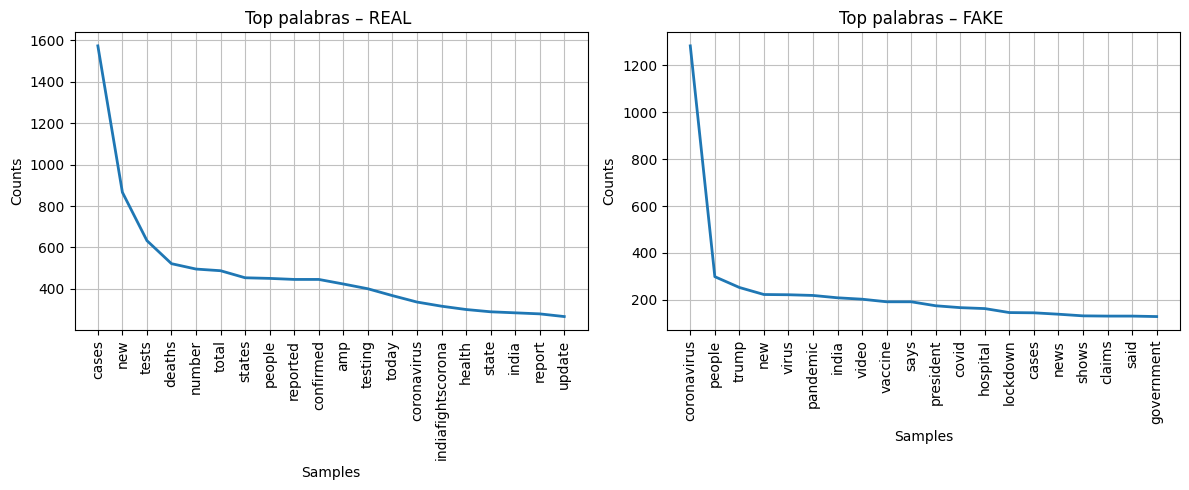

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
fdist_real_clean.plot(20, cumulative=False)
plt.title("Top palabras – REAL ")

plt.subplot(1,2,2)
fdist_fake_clean.plot(20, cumulative=False)
plt.title("Top palabras – FAKE ")

plt.tight_layout()
plt.show()

We can see that in fake tweets `coronavirus` predominates as the top word more than 1200 times. And in real tweets `cases` probably are tweets that report new or confirmed cases.

At first glance we can see that other words in fake tweets appear uniformly with no further predominance, meaning they are linguistically rich. While in real tweets we see much more `new`, `tests` or `deaths`.

### 1.3.7 N-grams

In [32]:
bigrams_real = list(ngrams(tokens_real_clean, 2))
bigrams_fake = list(ngrams(tokens_fake_clean, 2))

trigrams_real = list(ngrams(tokens_real_clean, 3))
trigrams_fake = list(ngrams(tokens_fake_clean, 3))

In [33]:
fdist_bi_real = FreqDist(bigrams_real)
fdist_bi_fake = FreqDist(bigrams_fake)

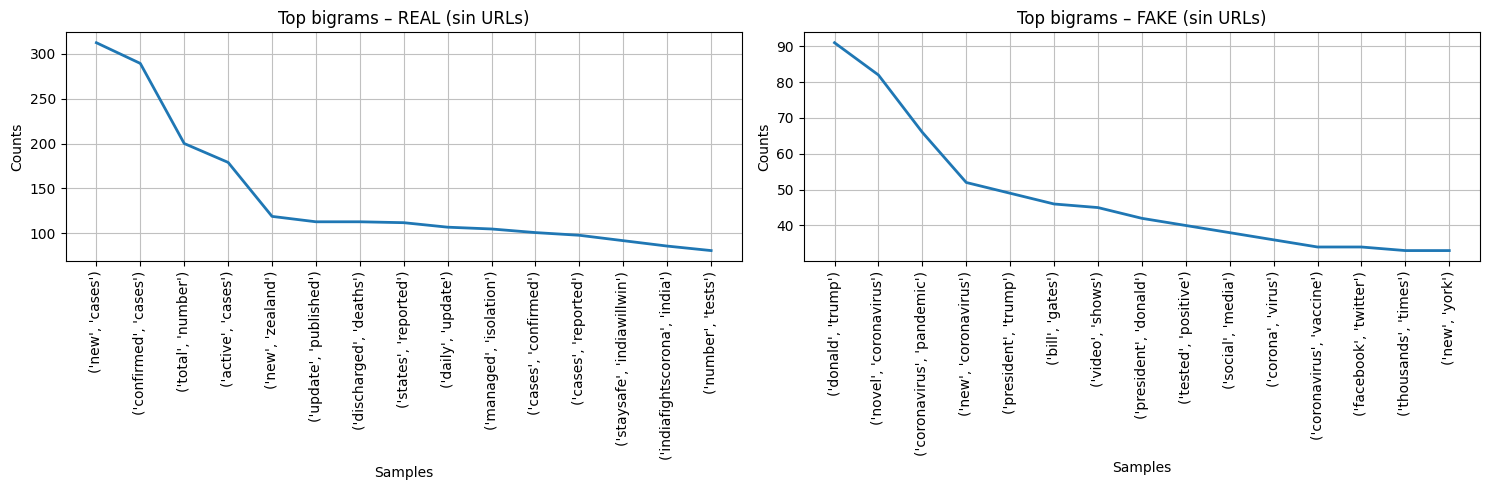

In [34]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
fdist_bi_real.plot(15, cumulative=False)
plt.title("Top bigrams – REAL (sin URLs)")

plt.subplot(1,2,2)
fdist_bi_fake.plot(15, cumulative=False)
plt.title("Top bigrams – FAKE (sin URLs)")

plt.tight_layout()
plt.show()

In n-grams we can see that the most common pair in real tweets is `new, cases` and `confirmed, cases` which tells us that real tweets are more related to new or confirmed cases and for example with `total, number` we can see what we saw at the beginning that they would be more related to putting figures.

As for fake tweets, the second most common is a link and then the word coronavirus probably hashtags that are usually put at the end right after the links like #coronavirus, as third we have `donald, trump` with almost 100 appearances.

We also have `coronavirus, pandemic` in fake tweets which we guess may be hashtags with the aim of drawing attention and alarming.

### 1.3.8 POS tagging

Continuing with linguistic analysis, now we will see analysis by pos tags, meaning word types.
Since there may be more real tweets than fake ones we will not use numbers but we will count and show percentages.

In [35]:
def pos_distribution(text):
    doc = nlp(text)
    return [token.pos_ for token in doc if token.is_alpha]

In [36]:
df['pos_tags'] = df['tweet'].astype(str).apply(pos_distribution)

In [37]:
# por clases
pos_real = [p for tags in df[df['label'] == 'real']['pos_tags'] for p in tags]
pos_fake = [p for tags in df[df['label'] == 'fake']['pos_tags'] for p in tags]
from collections import Counter

# Conteos
pos_real_counts = Counter(pos_real)
pos_fake_counts = Counter(pos_fake)

# Totales
total_pos_real = sum(pos_real_counts.values())
total_pos_fake = sum(pos_fake_counts.values())

# Frecuencias relativas
pos_real_freq = {k: v / total_pos_real for k, v in pos_real_counts.items()}
pos_fake_freq = {k: v / total_pos_fake for k, v in pos_fake_counts.items()}

In [38]:
pos_df = pd.DataFrame({
    'REAL': pd.Series(pos_real_freq),
    'FAKE': pd.Series(pos_fake_freq)
}).fillna(0)

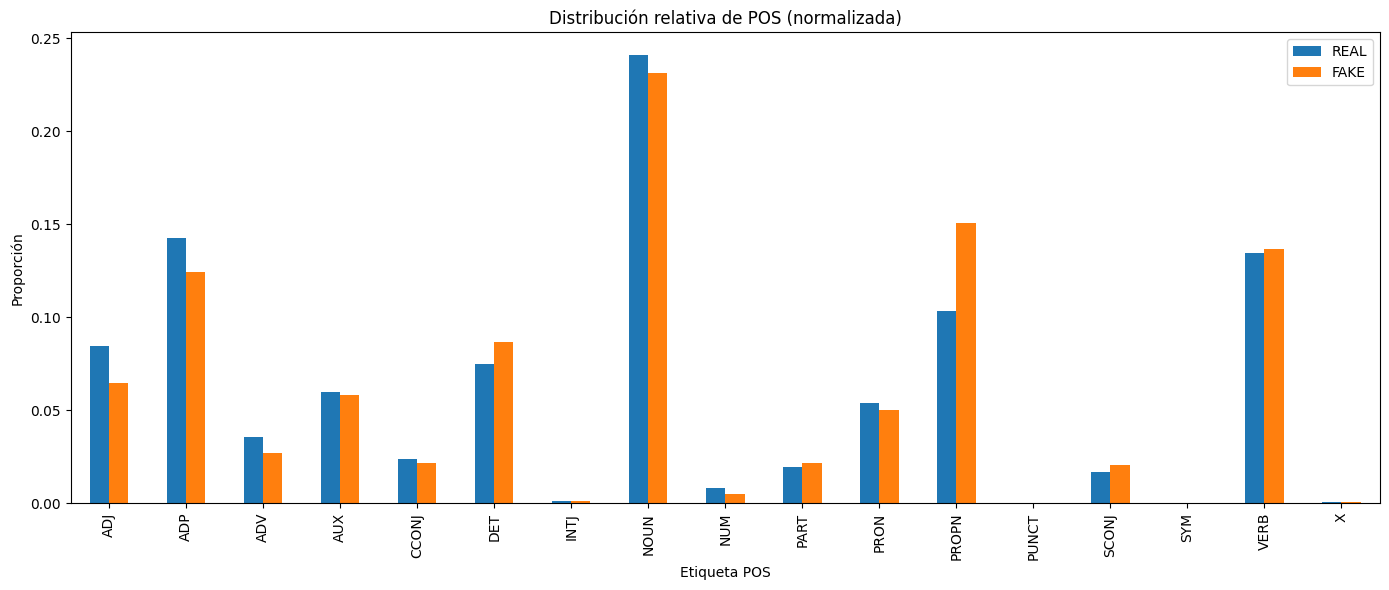

In [39]:
pos_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de POS (normalizada)")
plt.ylabel("Proporción")
plt.xlabel("Etiqueta POS")
plt.legend()
plt.tight_layout()
plt.show()

We can see that as expected, nouns predominate similarly in both, where we can see the greatest difference is in proper nouns where fake tweets predominate over real ones.

Perhaps this proper noun thing is because there tends to be a more personal language and more emotional or persuasive discourse.

### 1.3.9 Named Entity Recognition (NER)
It's like pos tags but with entities, but we will use nlp to classify tokens into real-world things and we will compare (using percentages).

In [40]:
def extract_entities(text):
    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

df['entities'] = df['tweet'].astype(str).apply(extract_entities)

In [41]:
entities_real = [e for ents in df[df['label'] == 'real']['entities'] for e in ents]
entities_fake = [e for ents in df[df['label'] == 'fake']['entities'] for e in ents]

In [42]:
ent_real_counts = Counter(entities_real)
ent_fake_counts = Counter(entities_fake)

total_ent_real = sum(ent_real_counts.values())
total_ent_fake = sum(ent_fake_counts.values())

In [43]:
ent_real_freq = {k: v / total_ent_real for k, v in ent_real_counts.items()}
ent_fake_freq = {k: v / total_ent_fake for k, v in ent_fake_counts.items()}

In [44]:
ent_df = pd.DataFrame({
    'REAL': pd.Series(ent_real_freq),
    'FAKE': pd.Series(ent_fake_freq)
}).fillna(0)

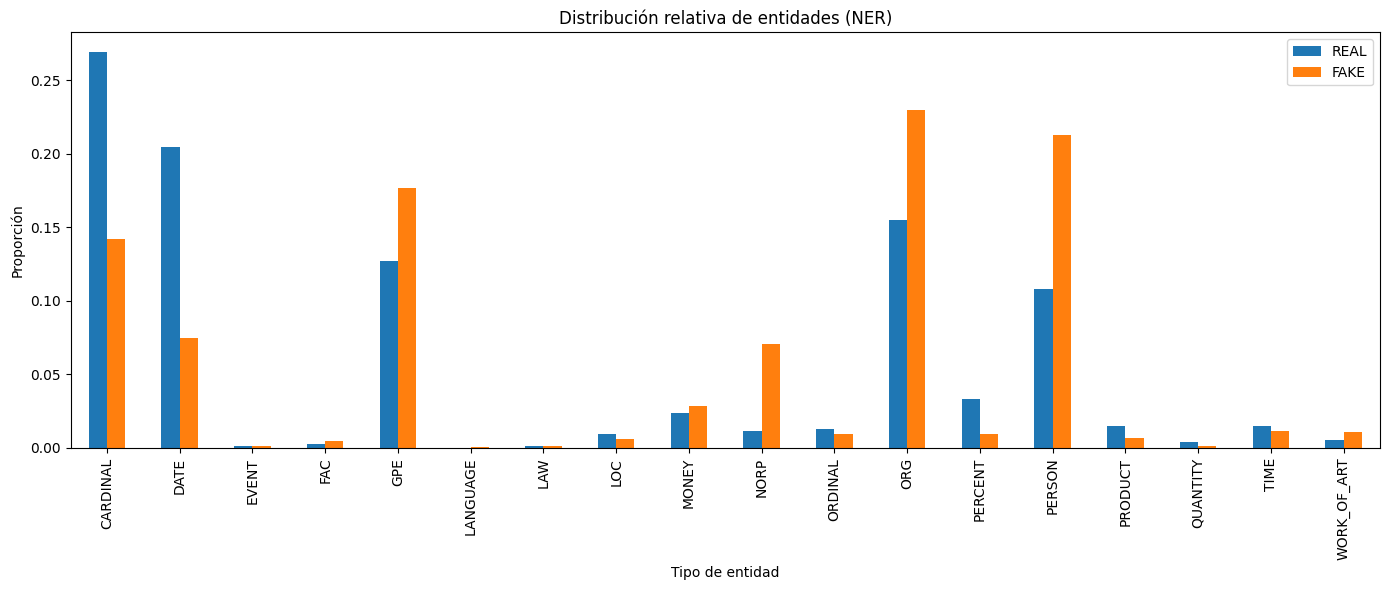

In [45]:
ent_df.plot(kind='bar', figsize=(14,6))
plt.title("Distribución relativa de entidades (NER)")
plt.ylabel("Proporción")
plt.xlabel("Tipo de entidad")
plt.legend()
plt.tight_layout()
plt.show()

Here we connect with what we said at the beginning that Real tweets have more numbers or figures than Fake tweets and this can be seen in the difference of the `Cardinal` entity, we also see that real tweets tend to have more dates.

As for Fake tweets they usually have more named persons in their tweets, perhaps it's a mechanism to attract attention as we saw with trump in the n-grams and they also predominate in ORG which are organizations also for the same reason to attract attention surely.

And we can see a very clear predominance in NORP although it is minimal compared to other percentages but they would be like political or religious groups which is logical in fake tweets.

### 1.3.10 Hashtags and mentions

In [46]:
def count_hashtags(text):
    return sum(1 for w in text.split() if w.startswith("#"))

def count_mentions(text):
    return sum(1 for w in text.split() if w.startswith("@"))

df['num_hashtags'] = df['tweet'].apply(count_hashtags)
df['num_mentions'] = df['tweet'].apply(count_mentions)

In [47]:
df.groupby('label')[['num_hashtags', 'num_mentions']].mean()

,num_hashtags,num_mentions
label,,
fake,0.508170,0.181046
real,1.052976,0.427381


Finally in this analysis, we can see that real tweets have a higher number of hashtags and mentions

## 1.4 Additional EDA Analysis
We are gona continue with more analisis.

### 1.4.1 Sentiment Analysis
We will analyze the emotional polarity of tweets to see if fake news tends to be more emotional or sensationalist.

We will use **VADER** that is used for short texts like the tweets we have

In [64]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [65]:
def sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return scores['compound']

In [84]:
df['sentiment'] = df['tweet'].astype(str).apply(sentiment_scores)

In [67]:
df.groupby('label')['sentiment'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,-0.063438,0.422348,-0.9914,-0.4019,0.0,0.2023,0.9688
real,3360.0,0.069161,0.406152,-0.9648,-0.1531,0.0,0.4019,0.9571


mean of sentiment: fake: −0.063 y real: +0.069. The fake ones have a slightly more negative and real are more positive.

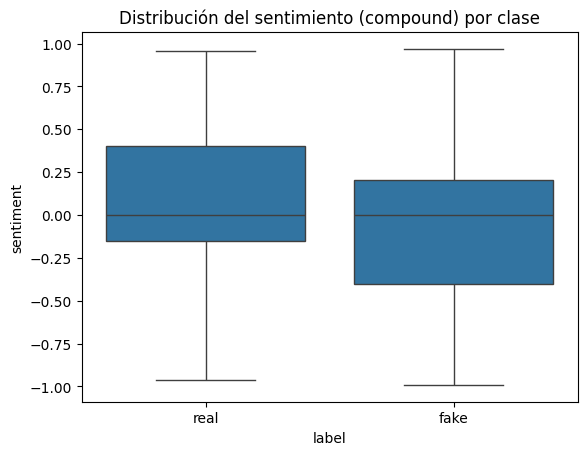

In [68]:
sns.boxplot(data=df, x='label', y='sentiment')
plt.title("Distribución del sentimiento (compound) por clase")
plt.show()

There we can se better that conclusion we have, the real ones tend to be more positive and fake more negative maybe there are more catrastofic and alert more bad things.

### 1.4.2 Mayus and puntuation analisis
We will se if fake tweets tend to use more mayus or more exclamation/interrogation signs.

In [69]:
def count_exclamations(text):
    return text.count('!')

def count_questions(text):
    return text.count('?')

def uppercase_ratio(text):
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)

In [70]:
df['num_exclamations'] = df['tweet'].astype(str).apply(count_exclamations)
df['num_questions'] = df['tweet'].astype(str).apply(count_questions)
df['uppercase_ratio'] = df['tweet'].astype(str).apply(uppercase_ratio)

By labes:

In [72]:
df.groupby('label')[['num_exclamations', 'num_questions', 'uppercase_ratio']].mean()

,num_exclamations,num_questions,uppercase_ratio
label,,,
fake,0.101307,0.430719,0.075805
real,0.016667,0.021429,0.078647


The fake tweets use more exclamations 0.101307 and far more questions 0.430719 but on the uppers there are a tie.

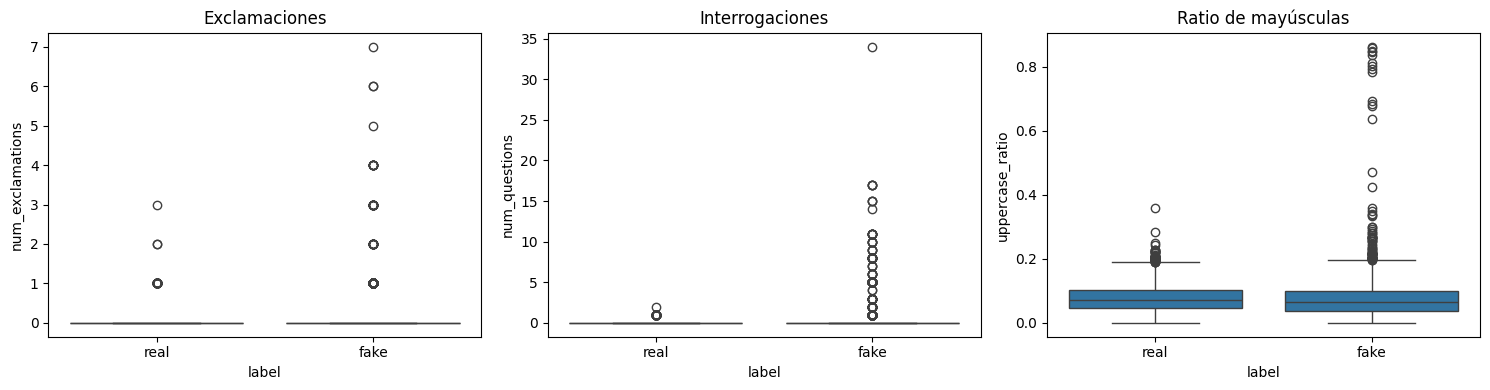

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='label', y='num_exclamations', ax=axes[0])
axes[0].set_title("Exclamaciones")

sns.boxplot(data=df, x='label', y='num_questions', ax=axes[1])
axes[1].set_title("Interrogaciones")

sns.boxplot(data=df, x='label', y='uppercase_ratio', ax=axes[2])
axes[2].set_title("Ratio de mayúsculas")

plt.tight_layout()
plt.show()

There we can see the same but the fake on the uppers tend to have more outliners than the real so some tweets may have a lot of uppers or be entirely uppers.

We can conclude that fake tweets have more exclamations and questions, and the tweets that have a lot of upper or entirely may be are fake.  

### 1.4.3 URLs and the shared domains

In [75]:
import re
from urllib.parse import urlparse

In [76]:
def extract_urls(text):
    return re.findall(r'https?://\S+|www\.\S+', text)

In [82]:
df['urls'] = df['tweet'].astype(str).apply(extract_urls)

In [78]:
def extract_domains(urls):
    domains = []
    for url in urls:
        try:
            parsed = urlparse(url if url.startswith('http') else 'http://' + url)
            domains.append(parsed.netloc)
        except:
            continue
    return domains

In [79]:
df['domains'] = df['urls'].apply(extract_domains)

By label:

In [80]:
domains_real = [d for domains in df[df['label'] == 'real']['domains'] for d in domains]
domains_fake = [d for domains in df[df['label'] == 'fake']['domains'] for d in domains]

FreqDist(domains_real).most_common(10)
FreqDist(domains_fake).most_common(10)

[('t.co', 1252),
 ('bit.ly', 1),
 ('www.tatahealth.com', 1),
 ('patents.justia.com', 1)]

The t.co domain clearly dominates the data set in both real and fake tweets.

This is because: t.co is the official shortener of Twitter.

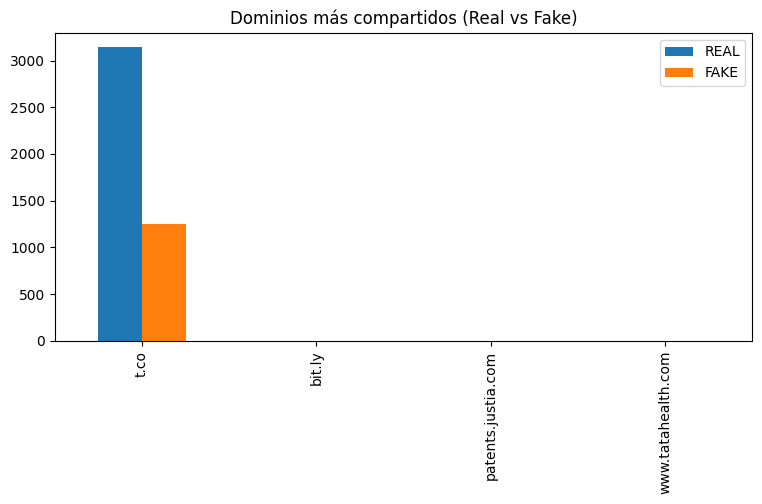

In [83]:
pd.DataFrame({
    'REAL': pd.Series(FreqDist(domains_real)),
    'FAKE': pd.Series(FreqDist(domains_fake))
}).fillna(0).sort_values(by='FAKE', ascending=False).head(10).plot(kind='bar', figsize=(9,4))

plt.title("Dominios más compartidos (Real vs Fake)")
plt.show()

As we see the domain use is not representative because of shortener of Twitter but we can clarely see real tweets have more than the double on links.

We can conclude saying real tweets tend to have more url.

## 2 Uninformed Search (BERTopic)
In the previous sections we have performed a linguistic analysis of the dataset to identify global latent patterns in the set of tweets.

But now we will do **topic modelling**, an unsupervised learning technique whose objective is to discover groups of documents that share similar semantic themes without the Real/Fake labels.

### 2.1 Clean the data
We need clean text without the labels (real/fake)

In [48]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # eliminar URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)        # solo letras
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df['cleaned_tweet'] = train_df['tweet'].astype(str).apply(clean_text)

### 2.2 Vector representation: embeddings

In [49]:
from sentence_transformers import SentenceTransformer

documents = train_df['cleaned_tweet'].tolist()

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/201 [00:00<?, ?it/s]

### 2.3 Elbow method adapted to nlp
Since there is no fixed `k` we will try different n_components in UMAP and measure clustering quality with silhouette score.
Note: clarify that this method is not necessary since it does not have the same effectiveness as with k-means

In [50]:
sil_scores = []
components_range = [2, 5, 10, 15, 20]

for n in components_range:
    umap_tmp = UMAP(
        n_neighbors=15,
        n_components=n,
        metric='cosine',
        random_state=42
    )
    reduced = umap_tmp.fit_transform(embeddings)

    cluster_tmp = HDBSCAN(min_cluster_size=15)
    labels_tmp = cluster_tmp.fit_predict(reduced)

    # ignoramos ruido (-1)
    mask = labels_tmp != -1
    if len(set(labels_tmp[mask])) > 1:
        score = silhouette_score(reduced[mask], labels_tmp[mask])
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

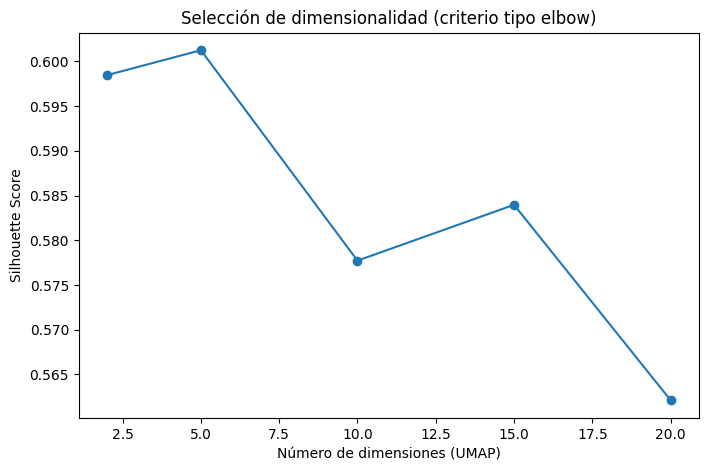

In [51]:
plt.figure(figsize=(8,5))
plt.plot(components_range, sil_scores, marker='o')
plt.xlabel("Número de dimensiones (UMAP)")
plt.ylabel("Silhouette Score")
plt.title("Selección de dimensionalidad (criterio tipo elbow)")
plt.show()

There is no clear elbow like with k-means but we can get something clear and that is that from 15.0 onwards there is a clear worsening we can say that from a certain number of dimensions adding more information introduces noise and worsens the separability of the clusters.

We can take 10.0 as value because it is in the "plateau" of the curve.

### 2.4 Final dimensionality reduction (UMAP)

In [52]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    metric='cosine',
    random_state=42
)

### 2.5 HDBSCAN

In [53]:
cluster_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

### 2.6 Topics representation

In [54]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


### 2.6 BERTopic model construction

In [55]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    language="english",
    verbose=True
)

### 2.7 Unsupervised training

In [56]:
topics, probs = topic_model.fit_transform(documents)

2026-01-04 17:50:44,821 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-04 17:52:36,692 - BERTopic - Embedding - Completed ✓
2026-01-04 17:52:36,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-04 17:52:53,652 - BERTopic - Dimensionality - Completed ✓
2026-01-04 17:52:53,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-04 17:52:55,341 - BERTopic - Cluster - Completed ✓
2026-01-04 17:52:55,347 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-04 17:52:55,865 - BERTopic - Representation - Completed ✓


### 2.8 Initial cluster analysis

In [57]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2821,-1_coronavirus_health_people_infected,"[coronavirus, health, people, infected, confirmed cases, home, spread, says, amp, india]","[coronavirusupdates total covid cases in india as on august cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths via mohfw india, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths staysafe]"
1,0,348,0_update published_daily update_published_states reported,"[update published, daily update, published, states reported, daily, published ve, ve tracked, tracked, tests yesterday, published states]","[our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked almost million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see]"
2,1,237,1_restrictions_uk_england_boris,"[restrictions, uk, england, boris, boris johnson, johnson, lockdown, london, scotland, covid restrictions]","[the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of coronavirus the health secretary has told sky news, the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of coronavirus the health secretary has told sky news, the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of covid health secretary matthancock has told sky news to read more click here]"
3,2,204,2_trump_donald trump_donald_donaldtrump,"[trump, donald trump, donald, donaldtrump, president, president trump, pandemic, obama, pandemic trump, trump administration]","[we re in the middle of a global pandemic and the trump administration is preventing people from getting health care i can t believe this needs to be said but president trump needs to reopen obamacare enrollment and he needs to do it now lives are at stake, we fact checked kamala harris hillary clinton and barack obama during their dnc speeches last night along with former obama harris issued a scathing indictment of president donald trump s handling of the covid pandemic, says donald trump tweeted i ordered the treasury secretary to send checks to americans first however we will go through your social media history from the last years and search for any post with notmypresident in it i wouldn t think of offending you with a check if i m not your president maga]"
4,3,143,3_nigeria_covid reported_reported nigeria_ncdc,"[nigeria, covid reported, reported nigeria, ncdc, chikwe, covid nigeria, nigeria discharged, pm th, molecular, april confirmed]","[today the honourable minister fmohnigeria convened a live press briefing to update nigerians on the ongoing response to the covid outbreak nigeria as at pm th march there have been cases of covid recorded in nigeria have been discharged with death, forty nine new cases of covid have been reported in lagos in fct in kano in ogun in oyo in ekiti as at pm th april there are confirmed cases of covid reported in nigeria discharged deaths takeresponsibility, eleven new cases of covid have been reported in lagos state as at pm th april there are confirmed cases of covid reported in nigeria have been discharged with deaths takeresponsibility]"
...

As we can see it gives us a total of 59 topics plus topic -1 which are: ambiguous tweets, tweets that are too short or tweets that do not clearly fit into any group and simply hdbscan does not force them into any topic.

What we see is:
- Topic: topic name
- Count: number of tweets in that topic
- Representation: most representative words
- Representative_Docs: prototype tweets

Tweets without topic (-1) are 2777 and the largest topics are `0_water_drinking_cure_alcohol, 1_restrictions_uk_boris_england and 2_trump_donald trump_donald_president` with more than 200 tweets.

### 2.9 Topics visualization

In [58]:
topic_model.visualize_topics()

We can see that there are many differentiated groups, the largest groups are where topic -1 is which are more general things like related to the origin of covid or names given to it (sars, cov..).

The second largest group is more related to politics (trump, belinda..) and misinformation.

There are two medium groups: one is more associated with science or data (records, reported, confirmed..) and the other more general like institutions (schools, hospitals..)

And other small groups like one related to measures (masks, clothes) and another that relates more to countries (italy, brazil..).

### 2.10 Topics distribution by real/fake labels
Now we will analyze which topics have the highest percentage of real tweets and which have the highest percentage of fake tweets.

In [59]:
# Add topics to the dataframe
train_df['topic'] = topics

In [60]:
# Calculate distribution of real/fake for each topic
topic_label_dist = train_df[train_df['topic'] != -1].groupby(['topic', 'label']).size().unstack(fill_value=0)

# Calculate percentages
topic_label_pct = topic_label_dist.div(topic_label_dist.sum(axis=1), axis=0) * 100

# Add topic names
topic_names = {row['Topic']: row['Name'] for _, row in topic_model.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct['topic_name'] = topic_label_pct.index.map(topic_names)

topic_label_pct.head(10)

label,fake,real,topic_name
topic,,,
0,2.011494,97.988506,0_update published_daily update_published_states reported
1,29.535865,70.464135,1_restrictions_uk_england_boris
2,98.529412,1.470588,2_trump_donald trump_donald_donaldtrump
3,6.993007,93.006993,3_nigeria_covid reported_reported nigeria_ncdc
4,96.296296,3.703704,4_water_drinking_drink_alcohol
5,99.253731,0.746269,5_chinese_china_wuhan_bidensoetoro
6,62.204724,37.795276,6_masks_mask_wearing_wear
7,97.500000,2.500000,7_italy_italian_italian doctors_died
8,23.893805,76.106195,8_covidview_covidview report_cdc covidview_latest cdc


In [61]:
# Sort topics by real percentage (descending)
topic_sorted = topic_label_pct.sort_values('real', ascending=False)

# Top 20 most real topics (first 20)
top_real = topic_sorted.head(20)[['real', 'fake', 'topic_name']]
print("Top 20 topics with highest REAL percentage:\n")
top_real

Top 20 topics with highest REAL percentage:



label,real,fake,topic_name
topic,,,
25,100.000000,0.000000,25_reported deaths_deaths today_day average_tues deaths
28,100.000000,0.000000,28_drtedros_drtedros covid_countries_health emergency
38,100.000000,0.000000,38_covid tests_tests lakh_indiafightscorona india_lakh tests
33,100.000000,0.000000,33_rt pib_pib india_pib_rt
58,100.000000,0.000000,58_cases miq_cases imported_miq facilities_facilities community
45,100.000000,0.000000,45_tests million_conducted hours_day million_diagnostic lab
47,100.000000,0.000000,47_arrived_hotel_case man_jet park
54,100.000000,0.000000,54_rt cdcdirector_cdcdirector_cdcdirector covid_learn rt
53,100.000000,0.000000,53_zealand receiving_level care_receiving hospital_hospital level


In [62]:
# Top 20 most fake topics (last 20)
top_fake = topic_sorted.tail(20)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False)
print("Top 20 topics with highest FAKE percentage:\n")
top_fake

Top 20 topics with highest FAKE percentage:



label,fake,real,topic_name
topic,,,
52,100.000000,0.000000,52_punishable_posting_disaster management_management act
39,100.000000,0.000000,39_case coronavirus_colombia_coronavirus confirmed_galicia
20,100.000000,0.000000,20_gates_foundation_gates foundation_melinda gates
15,100.000000,0.000000,15_beaten_video_muslim_police
5,99.253731,0.746269,5_chinese_china_wuhan_bidensoetoro
2,98.529412,1.470588,2_trump_donald trump_donald_donaldtrump
23,97.727273,2.272727,23_misinformation_fake_covid misinformation_debunked
7,97.500000,2.500000,7_italy_italian_italian doctors_died
4,96.296296,3.703704,4_water_drinking_drink_alcohol


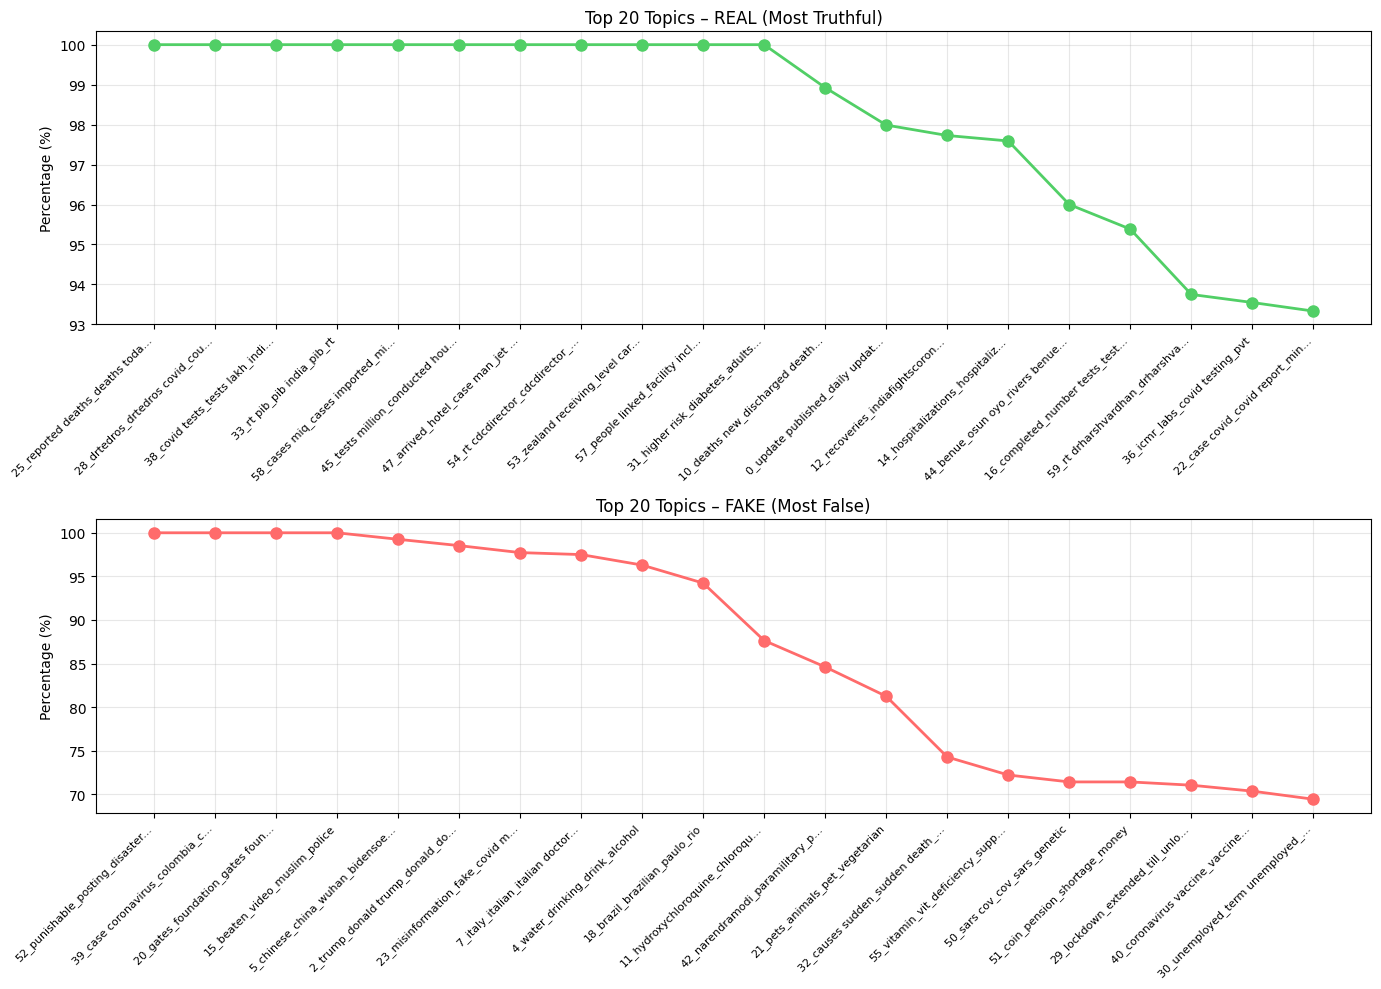

In [63]:
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
top_real_viz = top_real.sort_values('real', ascending=False)
plt.plot(range(len(top_real_viz)), top_real_viz['real'].values, 'o-', color='#51cf66', linewidth=2, markersize=8)
plt.xticks(range(len(top_real_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_real_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics – REAL (Most Truthful)')
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
top_fake_viz = top_fake.sort_values('fake', ascending=False)
plt.plot(range(len(top_fake_viz)), top_fake_viz['fake'].values, 'o-', color='#ff6b6b', linewidth=2, markersize=8)
plt.xticks(range(len(top_fake_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_fake_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics – FAKE (Most False)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis:**

The topics with the highest percentage of **FAKE** tweets (100% or near 100%) are:
- **Conspiracy theories about Bill Gates** (gates, gates foundation, melinda) - 100%
- **False remedies and cures** (water, drinking, alcohol) - 96.75%
- **Political misinformation** (trump, donald trump, president) - 96.46%
- **Origin theories** (chinese, china, wuhan, honjo) - 99.30%
- **Italy death toll misinformation** (italy, italian, died, dead bodies) - 97.98%
- **Fake news and misinformation** (misinformation, fake, debunked) - 100%
- **Unverified treatments** (hydroxychloroquine, chloroquine, drug) - 87.06%
- **Sensationalist predictions** (predicted, zoology book, sudden death) - 72.73%

The topics with the highest percentage of **REAL** tweets (100% or near 100%) are:
- **Official health reports** (rt cdcdirector, rt pib india) - 100%
- **Daily statistical updates** (daily update, published, states reported) - 97.50%
- **Deaths and recoveries data** (deaths new, discharged, confirmed, plateau) - 98.94%
- **Hospitalization data** (hospitalizations, hospitalization data) - 98.67%
- **Recovery statistics** (recoveries, recovery rate, indiafightscorona) - 98.39%
- **Regional outbreak reports** (nigeria, ncdc, andhra pradesh) - 94-98%
- **Health risk information** (higher risk, diabetes, type) - 100%
- **Quarantine facilities** (miq facilities, cases imported, community) - 100%
- **Medical facilities** (zealand receiving, hospital level care) - 100%
- **Public health guidance** (cloth face, face covering) - 93.02%

This analysis clearly shows that **FAKE tweets focus on conspiracy theories, unverified cures, political figures and fake statistics**, while **REAL tweets focus on official statistics, public health data, and government/medical institution reports**. The semantic themes are strongly predictive of tweet authenticity.